<a href="https://colab.research.google.com/github/zaradesouza/curso-labpol-2025/blob/main/Curso_Labpol_API_C%C3%A2mara_dos_Deputados_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Minicurso LabPol — para Dados Políticos e Sociais: Possibilidades, Ferramentas e Rotas de Análise (Text as Data)**
------------------------------------------------------------
Este notebook acompanha o curso do LabPol.
Objetivo: coletar dados da API da Câmara dos Deputados, organizar o corpus e aplicar
técnicas simples de PLN(classificação, TF-IDF, contagens e gráficos) para perguntas em
Ciência Política.

Fonte dos dados: API da Câmara dos Deputados: https://dadosabertos.camara.leg.br/swagger/api.html

Ministrante: Zara de Souza https://github.com/zaradesouza

In [ ]:
# ============================================
# Bibliotecas
# ============================================
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import seaborn as sns
import json
import re

# Instalação de dependências adicionais (executa uma única vez)
!pip install -q pysentimiento python-dateutil

from pysentimiento import create_analyzer
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from google.colab import files

In [ ]:
# ============================================
# Parâmetros da requisição
# ============================================

# IDs das proposições (lista de inteiros); deixe vazio para trazer todas
ids_proposicao = []

# Siglas de tipo de proposição (ex.: ["PL", "PEC"])
siglas_tipo = []

# Números oficiais das proposições (ex.: [1234, 5678])
numeros_proposicao = []

# Anos de apresentação das proposições (formato AAAA)
anos_proposicao = []

# Códigos numéricos de tipos de proposição
codigos_tipo = []

# IDs dos deputados autores (lista de inteiros)
ids_deputado_autor = []

# Parte do nome do autor (string ou None)
nome_autor = None  # ex.: "Silva"

# Siglas dos partidos dos autores
siglas_partido_autor = []  # ex.: ["PT", "PSDB"]

# Identificador numérico do partido do autor (ex.: 36839) ou None
id_partido_autor = None

# Siglas de UF dos autores (ex.: ["SP", "RJ"])
siglas_uf_autor = []

# Palavras‑chave sobre o tema da proposição:contentReference[oaicite:2]{index=2}
palavras_chave = [
    "violencia contra a mulher",
    "violencia contra mulher",
    "mulher",
    "feminicidio"
]

# Indicador se a proposição tramitou no Senado (True, False ou None)
tramitacao_senado = None

# # Intervalo de datas de tramitação (não deve exceder 3 meses por segmento)
# data_inicio = "2025-01-01"
# data_fim    = "2025-11-11"

# Intervalo de datas de apresentação (pode deixar None)
data_apresentacao_inicio = "2025-01-01"
data_apresentacao_fim    = "2025-11-11"

# Códigos de situação (lista de inteiros)
codigos_situacao = []

# Códigos de temas oficiais (lista de inteiros)
codigos_tema = []

# Paginação e ordenação
pagina_inicial   = 1
itens_por_pagina = 100
ordem      = "ASC"
ordenar_por = "id"

In [ ]:
# ============================================
# Montagem de parâmetros para a API
# ============================================
def construir_parametros():
    params = {}
    # Filtros de ID, tipo, número e ano
    if ids_proposicao:
        params["id"] = ",".join(map(str, ids_proposicao))
    if siglas_tipo:
        params["siglaTipo"] = ",".join(siglas_tipo)
    if numeros_proposicao:
        params["numero"] = ",".join(map(str, numeros_proposicao))
    if anos_proposicao:
        params["ano"] = ",".join(map(str, anos_proposicao))
    if codigos_tipo:
        params["codTipo"] = ",".join(map(str, codigos_tipo))
    # Filtros de autor
    if ids_deputado_autor:
        params["idDeputadoAutor"] = ",".join(map(str, ids_deputado_autor))
    if nome_autor:
        params["autor"] = nome_autor
    if siglas_partido_autor:
        params["siglaPartidoAutor"] = ",".join(siglas_partido_autor)
    if id_partido_autor is not None:
        params["idPartidoAutor"] = str(id_partido_autor)
    if siglas_uf_autor:
        params["siglaUfAutor"] = ",".join(siglas_uf_autor)
    # Palavras‑chave e tramitação no Senado
    if palavras_chave:
        params["keywords"] = ",".join(palavras_chave)
    if tramitacao_senado is not None:
        params["tramitacaoSenado"] = str(tramitacao_senado).upper()  # TRUE/FALSE
    # Datas de apresentação
    params["dataApresentacaoInicio"] = data_apresentacao_inicio
    params["dataApresentacaoFim"]    = data_apresentacao_fim
    # Códigos de situação e tema
    if codigos_situacao:
        params["codSituacao"] = ",".join(map(str, codigos_situacao))
    if codigos_tema:
        params["codTema"] = ",".join(map(str, codigos_tema))
    # Paginação e ordenação
    params["pagina"]     = pagina_inicial
    params["itens"]      = itens_por_pagina
    params["ordem"]      = ordem
    params["ordenarPor"] = ordenar_por
    return params

In [ ]:
# ============================================
# Funções de auxílio para datas e coleta
# ============================================
def gerar_segmentos_data(inicio_str, fim_str):
    """Divide o intervalo de datas em segmentos de no máximo 3 meses."""
    segmentos = []
    inicio = datetime.strptime(inicio_str, "%Y-%m-%d")
    fim    = datetime.strptime(fim_str, "%Y-%m-%d")
    atual = inicio
    while atual <= fim:
        proximo_fim = atual + relativedelta(months=3) - timedelta(days=1)
        if proximo_fim > fim:
            proximo_fim = fim
        segmentos.append((atual.date().isoformat(), proximo_fim.date().isoformat()))
        atual = proximo_fim + timedelta(days=1)
    return segmentos

def coletar_proposicoes(params):
    """Executa uma requisição ao endpoint /proposicoes com paginação automática."""
    url = "https://dadosabertos.camara.leg.br/api/v2/proposicoes"
    headers = {"accept": "application/json"}
    dados = []
    params_atual = params.copy()
    while True:
        resp = requests.get(url, params=params_atual, headers=headers)
        if resp.status_code != 200:
            print(f"Erro na requisição: {resp.status_code} - {resp.text}")
            break
        resultado = resp.json()
        dados.extend(resultado.get("dados", []))
        # Verifica se há próximo link
        next_link = None
        for link in resultado.get("links", []):
            if link.get("rel") == "next":
                next_link = link.get("href")
                break
        if not next_link:
            break
        url = next_link
        params_atual = {}  # parâmetros já incluídos no link
    return pd.json_normalize(dados)

def coletar_proposicoes_periodo(params):
    """
    Divide o período de apresentação em janelas de até 3 meses,
    coleta proposições em cada uma e concatena os resultados.
    """
    segmentos = gerar_segmentos_data(
        params["dataApresentacaoInicio"], params["dataApresentacaoFim"]
    )
    todos_df = []
    for seg_inicio, seg_fim in segmentos:
        params_seg = params.copy()
        params_seg["dataApresentacaoInicio"] = seg_inicio
        params_seg["dataApresentacaoFim"]    = seg_fim
        df_seg = coletar_proposicoes(params_seg)
        todos_df.append(df_seg)
    if todos_df:
        df_final = pd.concat(todos_df, ignore_index=True).drop_duplicates(subset="id")
        return df_final
    else:
        return pd.DataFrame()

In [ ]:
# Função para obter detalhes da proposição (data de apresentação etc.)
def coletar_detalhes_proposicao(proposicao_id):
    """
    Recupera detalhes de uma proposição (dataApresentacao, ementaDetalhada, etc.).
    Retorna um dicionário com essas informações.
    """
    url = f"https://dadosabertos.camara.leg.br/api/v2/proposicoes/{proposicao_id}"
    resp = requests.get(url, headers={"accept": "application/json"})
    if resp.status_code != 200:
        return {}
    dados = resp.json().get("dados", {})
    return {
        "dataApresentacao": dados.get("dataApresentacao"),
        "ementaDetalhada": dados.get("ementaDetalhada"),
        "ementaLei": dados.get("ementaDaLei"),
        "keywords": ",".join(dados.get("keywords", [])) if isinstance(dados.get("keywords"), list) else dados.get("keywords")
    }


In [ ]:
# Função para coletar autores

def coletar_autores_e_partidos(proposicao_id):
    """
    Para cada proposição, consulta /proposicoes/{id}/autores e,
    quando o autor for deputado(a), consulta /deputados/{id} para obter:
    - nome do autor
    - sigla do partido do autor
    - gênero do autor (M/F na API; aqui mapeado p/ 'Masculino'/'Feminino')
    Retorna: (lista_nomes, lista_siglas_partido, lista_generos)
    """
    url_autores = f"https://dadosabertos.camara.leg.br/api/v2/proposicoes/{proposicao_id}/autores"
    resp = requests.get(url_autores, headers={"accept": "application/json"})
    if resp.status_code != 200:
        return [], [], []

    autores = resp.json().get("dados", [])
    nomes, siglas_partido, generos = [], [], []

    for autor in autores:
        nome_autor = autor.get("nome")
        nomes.append(nome_autor)

        sigla = None
        genero = None

        uri_deputado = autor.get("uri")  # quando é deputado(a), vem a URI do recurso /deputados/{id}
        if uri_deputado and "/deputados/" in uri_deputado:
            try:
                resp_dep = requests.get(uri_deputado, headers={"accept": "application/json"})
                if resp_dep.status_code == 200:
                    dep = resp_dep.json().get("dados", {})
                    ultimo = dep.get("ultimoStatus", {})

                    # partido
                    sigla = (ultimo.get("siglaPartido")
                             or dep.get("siglaPartido")
                             or None)

                    # gênero
                    sexo_api = (dep.get("sexo") or ultimo.get("sexo"))
                    if isinstance(sexo_api, str):
                        genero = {"M": "Masculino", "F": "Feminino"}.get(sexo_api.upper(), sexo_api)
            except Exception:
                pass

        siglas_partido.append(sigla)
        generos.append(genero)

    return nomes, siglas_partido, generos


In [ ]:
# Função para coletar temas das proposições

def coletar_temas_proposicao(proposicao_id):
    """
    Chama /proposicoes/{id}/temas e retorna (lista_de_temas_ordenada, tema_principal).
    O tema_principal é o de maior 'relevancia' segundo o CEDI/Câmara.
    """
    url = f"https://dadosabertos.camara.leg.br/api/v2/proposicoes/{proposicao_id}/temas"
    try:
        resp = requests.get(url, headers={"accept": "application/json"}, timeout=30)
        if resp.status_code != 200:
            return [], None
        dados = resp.json().get("dados", [])
        if not dados:
            return [], None
        # ordena por relevancia (desc), protegendo quando campo não vier
        dados_sorted = sorted(dados, key=lambda x: x.get("relevancia", 0), reverse=True)
        temas = [d.get("tema") for d in dados_sorted if d.get("tema")]
        tema_principal = temas[0] if temas else None
        return temas, tema_principal
    except Exception:
        return [], None


def adicionar_temas(df):
    """
    Para cada proposição em df['id'], anexa:
      - 'temasCamara': lista de temas (ordenada por relevancia desc)
      - 'temaCamara': tema de maior relevancia (string)
    """
    listas_temas = []
    temas_principais = []
    for pid in df["id"]:
        temas, tema_princ = coletar_temas_proposicao(pid)
        listas_temas.append(temas)
        temas_principais.append(tema_princ)

    df["temasCamara"] = listas_temas
    df["temaCamara"]  = temas_principais
    return df


In [ ]:
def adicionar_detalhes_e_autores(df):
    """
    Para cada proposição:
      - adiciona detalhes via /proposicoes/{id}
      - adiciona autores (nomes), partidos e gênero (quando disponível)
    Novas colunas:
      dataApresentacao, ementaDetalhada, keywords,
      nomesAutores (lista), siglaPartidoAutor (lista), generoAutores (lista)
    """
    detalhes_list = []
    nomes_list, partidos_list, generos_list = [], [], []

    for pid in df["id"]:
        # Detalhes
        det = coletar_detalhes_proposicao(pid)
        detalhes_list.append(det)

        # Autores / Partidos / Gênero
        nomes, siglas, generos = coletar_autores_e_partidos(pid)
        nomes_list.append(nomes)
        partidos_list.append(siglas)
        generos_list.append(generos)

    # Campos de detalhes
    df["dataApresentacao"] = [d.get("dataApresentacao") for d in detalhes_list]
    df["ementaDetalhada"]  = [d.get("ementaDetalhada")  for d in detalhes_list]
    df["keywords"]         = [d.get("keywords")         for d in detalhes_list]

    # Autores/partidos/gênero
    df["nomesAutores"]       = nomes_list
    df["siglaPartidoAutor"]  = partidos_list
    df["generoAutores"]      = generos_list

    return df


In [ ]:
# ============================================
# Funções para recuperar autores (incluindo partidos)
# ============================================
def coletar_autores_proposicao(proposicao_id):
    """
    Para um ID de proposição, recupera uma lista de autores.
    Retorna lista de dicionários com campos como 'nome', 'siglaPartido', etc.
    """
    url = f"https://dadosabertos.camara.leg.br/api/v2/proposicoes/{proposicao_id}/autores"
    resp = requests.get(url, headers={"accept": "application/json"})
    if resp.status_code != 200:
        return []
    return resp.json().get("dados", [])

def adicionar_partidos_autores(df):
    """
    Percorre cada proposição para obter partidos dos autores e inclui no DataFrame
    uma coluna 'siglaPartidoAutor' contendo lista de siglas (ou string vazia).
    """
    partidos_map = {}
    for pid in df["id"]:
        autores = coletar_autores_proposicao(pid)
        siglas = []
        for autor in autores:
            sigla = autor.get("siglaPartido")
            if sigla:
                siglas.append(sigla)
        partidos_map[pid] = siglas
    # Cria coluna com listas de partidos (ou lista vazia)
    df["siglaPartidoAutor"] = df["id"].map(partidos_map)
    return df


In [ ]:
# ============================================
# Coleta de dados
# ============================================
print("Baixando proposições (por períodos de 3 meses)...")
params = construir_parametros()
df_proposicoes = coletar_proposicoes_periodo(params)
print(f"Foram coletadas {len(df_proposicoes)} proposições.")

Baixando proposições (por períodos de 3 meses)...
Foram coletadas 290 proposições.


In [ ]:
# ============================================
# Inclusão de todos os dados disponíveis (autores e partidos)
# ============================================

df_proposicoes = adicionar_detalhes_e_autores(df_proposicoes)

In [ ]:
# ============================================
# Inclusão dos temas
# ============================================
df_proposicoes = adicionar_temas(df_proposicoes)

In [ ]:
# ============================================
# Análise de sentimento (pysentimiento em português)
# ============================================
analisador_sentimento = create_analyzer(task="sentiment", lang="pt")

def classificar_sentimento(texto):
    if not isinstance(texto, str) or texto.strip() == "":
        return "neutra"
    resultado = analisador_sentimento.predict(texto)
    mapeamento = {"POS": "positiva", "NEG": "negativa", "NEU": "neutra"}
    return mapeamento.get(resultado.output, "neutra")

# Concatena ementa e ementaDetalhada de forma segura
texto_ementa = df_proposicoes["ementa"].fillna("")
# Se a coluna ementaDetalhada não existir, cria série vazia do mesmo tamanho
if "ementaDetalhada" in df_proposicoes.columns:
    texto_detalhada = df_proposicoes["ementaDetalhada"].fillna("")
else:
    texto_detalhada = pd.Series([""] * len(df_proposicoes), index=df_proposicoes.index)
# Une ementa e ementaDetalhada
texto_unido = texto_ementa.str.cat(texto_detalhada, sep=" ")
# Aplica o classificador
df_proposicoes["sentimento"] = texto_unido.apply(classificar_sentimento)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/952 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/562 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

In [ ]:
# ============================================
# Classificação temática (dicionário simples)
# ============================================
dicionario_temas = {
    "Violência": [
        "violencia", "violência", "agressão", "abuso",
        "feminicidio", "feminicídio", "maria da penha", "agressor"
    ],
    "Saúde": [
        "saúde", "saude", "reprodutiva", "hospital",
        "assistência", "assistencia", "câncer", "cancer",
        "prevenção", "prevencao", "aborto"
    ],
    "Trabalho/Licença": [
        "licença", "licenca", "maternidade", "paternidade",
        "parental", "trabalho", "emprego", "servidora", "servidor"
    ],
    "Participação política": [
        "cotas", "representação", "representacao", "partido",
        "candidatura", "eleição", "eleicao", "paridade",
        "comissão", "comissao"
    ]
}

def atribuir_tema(ementa):
    if not isinstance(ementa, str):
        return "Outros"
    ementa_lower = ementa.lower()
    for tema, termos in dicionario_temas.items():
        if any(t in ementa_lower for t in termos):
            return tema
    return "Outros"

df_proposicoes["tema"] = df_proposicoes["ementa"].fillna("").apply(atribuir_tema)


In [ ]:
df_proposicoes

,id,uri,siglaTipo,codTipo,numero,ano,ementa,dataApresentacao,ementaDetalhada,keywords,nomesAutores,siglaPartidoAutor,generoAutores,temasCamara,temaCamara,sentimento,tema
0,2481880,https://dadosabertos.camara.leg.br/api/v2/prop...,MPV,291,1287,2025,Institui apoio financeiro à pessoa com deficiê...,2025-01-09T00:00,,"Criação, auxílio financeiro, criança com defic...",[Poder Executivo],[None],[None],"[Direitos Humanos e Minorias, Finanças Pública...",Direitos Humanos e Minorias,neutra,Outros
1,2482269,https://dadosabertos.camara.leg.br/api/v2/prop...,PL,139,65,2025,Institui a obrigatoriedade de cláusula contrat...,2025-02-03T09:37,,"Obrigatoriedade, cláusula contratual, proibiçã...",[Pedro Aihara],[PRD],[Masculino],"[Administração Pública, Arte, Cultura e Religi...",Administração Pública,negativa,Violência
2,2482275,https://dadosabertos.camara.leg.br/api/v2/prop...,PL,139,68,2025,"Altera a Lei nº 14.192, de 2021, que dispõe so...",2025-02-03T09:52,,"Alteração, lei federal, Código Eleitoral (1965...",[Daiana Santos],[PCdoB],[Feminino],"[Direitos Humanos e Minorias, Política, Partid...",Direitos Humanos e Minorias,neutra,Violência
3,2482294,https://dadosabertos.camara.leg.br/api/v2/prop...,PL,139,77,2025,"Estabelece, como diretriz geral, que deve ser ...",2025-02-03T10:10,,"Obrigatoriedade, anuência, participação, mulhe...",[Dayany Bittencourt],[UNIÃO],[Feminino],"[Administração Pública, Direitos Humanos e Min...",Administração Pública,neutra,Outros
4,2482318,https://dadosabertos.camara.leg.br/api/v2/prop...,PL,139,85,2025,Institui a garantia de acesso universal ao tra...,2025-02-03T10:44,,"Garantia, acesso, mulher, tratamento de saúde,...",[Icaro de Valmir],[PL],[Masculino],"[Direitos Humanos e Minorias, Homenagens e Dat...",Direitos Humanos e Minorias,neutra,Saúde
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
285,2582052,https://dadosabertos.camara.leg.br/api/v2/prop...,PL,139,5695,2025,Institui o Programa Nacional de Acolhimento e ...,2025-11-05T15:20,,"Criação, Programa Nacional de Acolhimento e Pr...",[Marcos Tavares],[PDT],[Masculino],"[Direitos Humanos e Minorias, Saúde, Trabalho ...",Direitos Humanos e Minorias,neutra,Violência
286,2582055,https://dadosabertos.camara.leg.br/api/v2/prop...,PL,139,5697,2025,Institui o Programa Nacional de Acompanhamento...,2025-11-05T15:27,,"Criação, Programa Nacional de Acompanhamento P...",[Marcos Tavares],[PDT],[Masculino],"[Direitos Humanos e Minorias, Saúde]",Direitos Humanos e Minorias,neutra,Saúde
287,2582263,https://dadosabertos.camara.leg.br/api/v2/prop...,PLP,140,235,2025,Dá nova disciplina ao Fundo Nacional de Segura...,2025-11-05T20:12,Altera a Lei nº 13.756 de 2018 e revoga a Lei ...,"Disciplinamento, Fundo Nacional de Segurança P...","[Aécio Neves, Paulo Abi-Ackel]","[PSDB, PSDB]","[Masculino, Masculino]","[Defesa e Segurança, Finanças Públicas e Orçam...",Defesa e Segurança,neutra,Outros
288,2583551,https://dadosabertos.camara.leg.br/api/v2/prop...,PL,139,5780,2025,Institui a Política Nacional de Padrões e Meta...,2025-11-11T10:53,,"Criação, Política Nacional de Padrões e Metas ...",[Romero Rodrigues],[PODE],[Masculino],"[Administração Pública, Defesa e Segurança, Di...",Administração Pública,neutra,Violência


In [ ]:
# Salvar como CSV e baixar no Colab

caminho = "/content/df_proposicoes.csv"
df_proposicoes.to_csv(caminho, index=False, encoding="utf-8")
files.download(caminho)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipython-input-2128892300.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


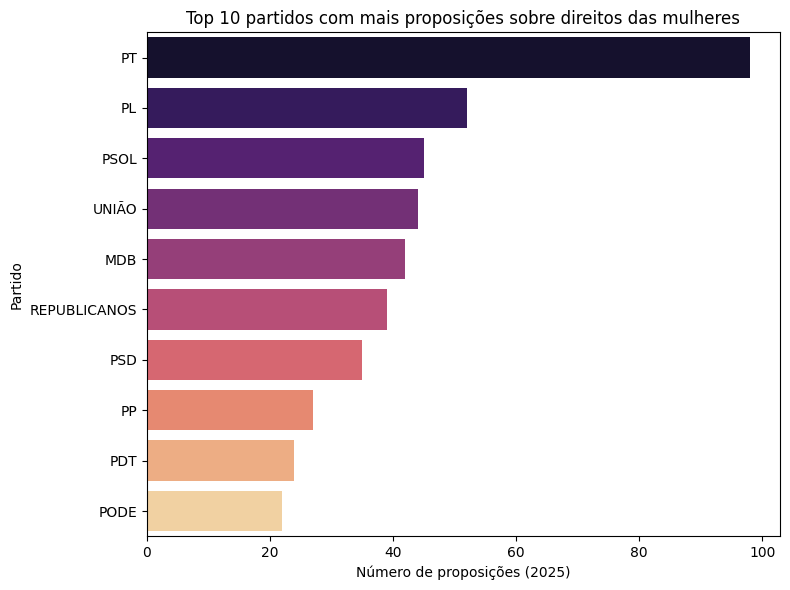

In [ ]:
# ============================================
# Gráfico Top 10 partidos com mais proposições
# ============================================
# Aqui usamos a coluna 'siglaPartidoAutor' (lista de siglas por proposição)
if "siglaPartidoAutor" in df_proposicoes.columns:
    # Explode as listas para contar individualmente
    df_partidos = df_proposicoes[["id", "siglaPartidoAutor"]].explode("siglaPartidoAutor")
    contagem_partidos = (
        df_partidos["siglaPartidoAutor"]
        .dropna()
        .value_counts()
        .head(10)
    )
    plt.figure(figsize=(8, 6))
    sns.barplot(
        x=contagem_partidos.values,
        y=contagem_partidos.index,
        palette="magma"
    )
    plt.xlabel("Número de proposições (2025)")
    plt.ylabel("Partido")
    plt.title("Top 10 partidos com mais proposições sobre direitos das mulheres")
    plt.tight_layout()
    plt.show()
else:
    print("A coluna 'siglaPartidoAutor' não está presente no dataset.")


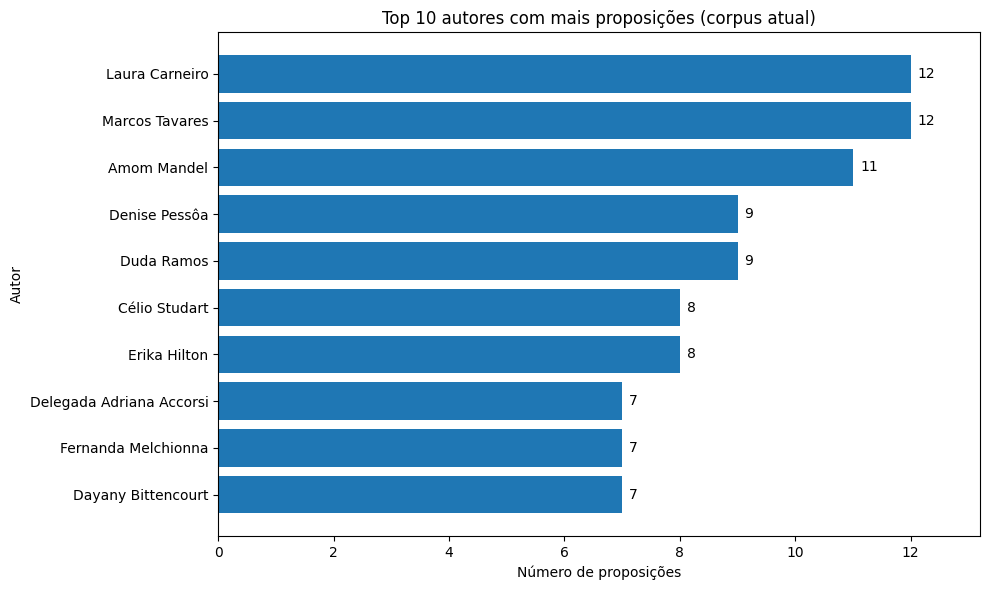

In [ ]:
# ============================================
# Gráfico Top 10 autores com mais proposições
# ============================================

def _extrai_nomes(x):
    if isinstance(x, (list, tuple, set)):
        nomes = []
        for item in x:
            if isinstance(item, str):
                nomes += [p.strip() for p in re.split(r";|,", item) if p and p.strip()]
            elif isinstance(item, dict):
                for k in ("nome", "nomeAutor", "autor", "nome_autor"):
                    if k in item and item[k]:
                        nomes.append(str(item[k]).strip())
                        break
            elif pd.notna(item):
                nomes.append(str(item).strip())
        return nomes
    elif isinstance(x, str):
        return [p.strip() for p in re.split(r";|,", x) if p and p.strip()]
    else:
        return []

serie_autores = (
    df_proposicoes["nomesAutores"]
    .apply(_extrai_nomes)
    .explode()
    .dropna()
    .astype(str)
    .str.strip()
)
serie_autores = serie_autores[serie_autores.ne("") & serie_autores.ne("nan")]

if serie_autores.empty:
    print("Não há nomes de autores válidos em 'nomesAutores'.")
else:
    # conta, pega top10 e ordena para plot horizontal crescente
    top_s = serie_autores.value_counts().head(10).sort_values(ascending=True)
    top = top_s.reset_index()
    top.columns = ["Autor", "Proposições"]

    plt.figure(figsize=(10, 6))
    bars = plt.barh(top["Autor"], top["Proposições"])

    # adiciona rótulos com o número em cada barra
    xmax = top["Proposições"].max()
    for rect, v in zip(bars, top["Proposições"]):
        plt.text(v + xmax*0.01, rect.get_y() + rect.get_height()/2,
                 f"{int(v)}", va="center", ha="left")

    plt.xlim(0, xmax * 1.10)
    plt.xlabel("Número de proposições")
    plt.ylabel("Autor")
    plt.title("Top 10 autores com mais proposições (corpus atual)")
    plt.tight_layout()
    plt.show()


Colunas disponíveis: ['ano', 'codTipo', 'dataApresentacao', 'ementa', 'ementaDetalhada', 'generoAutores', 'id', 'keywords', 'nomesAutores', 'numero', 'sentimento', 'siglaPartidoAutor', 'siglaTipo', 'tema', 'temaCamara', 'temasCamara', 'uri']


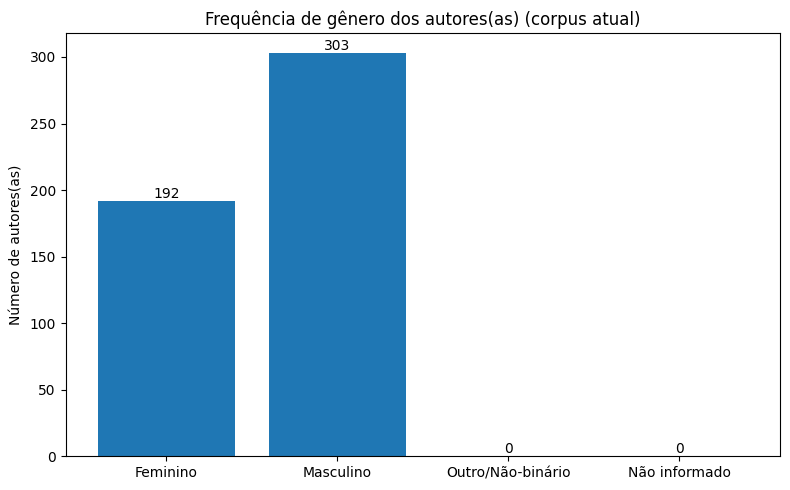

In [ ]:
# ============================================
# Frequência de Gênero dos autores
# ============================================

# 1) Conferir as colunas disponíveis
print("Colunas disponíveis:", sorted(df_proposicoes.columns.tolist()))
if "generoAutores" not in df_proposicoes.columns:
    raise KeyError("A coluna 'generoAutores' não existe em df_proposicoes. Verifique o nome exato da coluna.")

def _extrai_generos(x):
    """
    Converte diferentes formatos de 'generoAutores' em uma lista de rótulos.
    Aceita:
      - lista/tupla/conjunto de strings
      - lista com dicionários (usa chaves 'genero','sexo','gender' se existirem)
      - string única (divide por ';' ou ',')
    """
    if isinstance(x, (list, tuple, set)):
        out = []
        for item in x:
            if isinstance(item, dict):
                for k in ("genero", "sexo", "gender"):
                    if k in item and item[k]:
                        out.append(str(item[k]).strip())
                        break
            elif isinstance(item, str):
                out.extend([p.strip() for p in re.split(r";|,", item) if p and p.strip()])
            elif pd.notna(item):
                out.append(str(item).strip())
        return out
    elif isinstance(x, str):
        return [p.strip() for p in re.split(r";|,", x) if p and p.strip()]
    else:
        return []

def _sem_acentos(s: str) -> str:
    s = unicodedata.normalize("NFD", s)
    return "".join(ch for ch in s if not unicodedata.combining(ch))

def _normaliza_genero(g: str) -> str:
    """
    Normaliza rótulos de gênero para quatro categorias:
    'Feminino', 'Masculino', 'Outro/Não-binário', 'Não informado'
    """
    if not isinstance(g, str) or g.strip() == "":
        return "Não informado"
    x = _sem_acentos(g.strip().lower())

    fem = {"f", "fem", "feminino", "feminina", "female", "mulher"}
    mas = {"m", "masc", "masculino", "masculina", "male", "homem"}
    nb  = {"nao binario", "nao-binario", "nonbinary", "non-binary", "nb", "outro", "outros", "intersexo", "intersex"}

    nao_info = {
        "nao informado", "nao-informado", "desconhecido", "ignorado",
        "indefinido", "n/a", "na", "ni", "null", "none"
    }

    if x in fem:
        return "Feminino"
    if x in mas:
        return "Masculino"
    if x in nb or "nao bin" in x:
        return "Outro/Não-binário"
    if x in nao_info:
        return "Não informado"
    # fallback: tenta mapear por palavras-chave
    if "fem" in x or "mulher" in x:
        return "Feminino"
    if "masc" in x or "homem" in x:
        return "Masculino"
    return "Outro/Não-binário"

# 2) Explodir a coluna em uma série (um autor por linha) e normalizar
serie_generos = df_proposicoes["generoAutores"].apply(_extrai_generos).explode()
serie_generos = serie_generos.dropna().astype(str).str.strip()
serie_generos = serie_generos[serie_generos.ne("") & serie_generos.ne("nan")]
serie_generos_norm = serie_generos.map(_normaliza_genero)

if serie_generos_norm.empty:
    print("Não há valores válidos em 'generoAutores'.")
else:
    # 3) Contagem por categoria com ordem amigável
    ordem = ["Feminino", "Masculino", "Outro/Não-binário", "Não informado"]
    contagem = serie_generos_norm.value_counts()
    contagem = contagem.reindex(ordem, fill_value=0)

    # 4) Gráfico de barras verticais
    plt.figure(figsize=(8, 5))
    plt.bar(contagem.index, contagem.values)
    plt.ylabel("Número de autores(as)")
    plt.title("Frequência de gênero dos autores(as) (corpus atual)")
    # rótulos de contagem acima das barras
    for i, v in enumerate(contagem.values):
        plt.text(i, v, str(v), ha="center", va="bottom")
    plt.tight_layout()
    plt.show()


In [ ]:
# ============================================
# Resumos finais
# ============================================
print("\nDistribuição de temas:")
print(df_proposicoes["tema"].value_counts())

print("\nDistribuição de sentimento:")
print(df_proposicoes["sentimento"].value_counts())

# Exibe primeiras linhas com colunas principais, incluindo partidos
colunas_exibir = [
    "id", "siglaTipo", "numero", "ano",
    "ementa", "tema", "sentimento",
    "siglaPartidoAutor", "dataApresentacao"
]
# Garante que todas as colunas existam para evitar erro de KeyError
for col in colunas_exibir:
    if col not in df_proposicoes.columns:
        df_proposicoes[col] = np.nan
df_proposicoes[colunas_exibir].head()


Distribuição de temas:
tema
Violência                135
Outros                    85
Saúde                     45
Trabalho/Licença          18
Participação política      7
Name: count, dtype: int64

Distribuição de sentimento:
sentimento
neutra      284
negativa      6
Name: count, dtype: int64


,id,siglaTipo,numero,ano,ementa,tema,sentimento,siglaPartidoAutor,dataApresentacao
0,2481880,MPV,1287,2025,Institui apoio financeiro à pessoa com deficiê...,Outros,neutra,[None],2025-01-09T00:00
1,2482269,PL,65,2025,Institui a obrigatoriedade de cláusula contrat...,Violência,negativa,[PRD],2025-02-03T09:37
2,2482275,PL,68,2025,"Altera a Lei nº 14.192, de 2021, que dispõe so...",Violência,neutra,[PCdoB],2025-02-03T09:52
3,2482294,PL,77,2025,"Estabelece, como diretriz geral, que deve ser ...",Outros,neutra,[UNIÃO],2025-02-03T10:10
4,2482318,PL,85,2025,Institui a garantia de acesso universal ao tra...,Saúde,neutra,[PL],2025-02-03T10:44


## Exercício 1 — Top 10 tipos de proposição
**Objetivo:** identificar os tipos mais frequentes (PL, PDL, PEC etc.).

**Passos sugeridos**
- Inspecione `df_proposicoes.columns` e selecione a coluna que contém as siglas dos tipos de proposições.

- Padronize valores como *strings* simples (se vier lista, exploda ou junte).  
  *Dicas:* `astype(str)`, `str.strip()`, `explode()`, `apply()`.

- Calcule frequências e ordene; pegue os 10 primeiros.  
  *Dicas:* `value_counts()`, `sort_values()`, `head(10)`.

- Visualização (opcional): gráfico de barras horizontais.  
  *Dicas:* `plt.barh()`, `plt.title()`, `plt.xlabel()`, `plt.tight_layout()`.

---

## Exercício 2 — Meses com maior atividade
**Objetivo:** medir a atividade mensal (quantidade de proposições por mês).

**Passos sugeridos**
- Escolha a coluna de data.

- Converta para `datetime`, tratando a formatação corretamente.  
  *Dica:* `pd.to_datetime(col, errors="coerce")`.

- Derive o campo ano-mês (`YYYY-MM`).  
  *Dicas:* `datas.dt.to_period("M").astype(str)` ou `datas.dt.strftime("%Y-%m")`.
- Conte por mês e ordene (por índice para ordem temporal, ou por valor para Top N).  
  *Dicas:* `value_counts()`, `sort_index()`, `sort_values()`.

- Visualização (opcional): gráfico de barras dos 12 meses mais ativos.  
  *Dicas:* `plt.bar()`, `plt.xticks(rotation=45)`, `plt.tight_layout()`.
  
---

## Exercício 3 — TF-IDF das ementas (unigramas e bigramas)
**Objetivo:** encontrar termos/expressões característicos do corpus.

**Passos sugeridos**
- Monte o texto: usar `ementa` (e opcionalmente `ementaDetalhada`), tratando nulos como vazio.

- Pré-processamento leve: minúsculas, remoção de acentos (opcional), limpeza mínima. **Não** remova negações (“não”, “sem”) nem números de leis.  
  *Dicas:* `str.lower()`, normalização Unicode, `fillna("")`.

- Vetorização com `TfidfVectorizer` (scikit-learn).  
  *Sugestões de parâmetros:* `lowercase=True`, `strip_accents="unicode"`, `ngram_range=(1,2)`, `min_df=2`, `max_df=0.8`, `stop_words` (lista PT-BR).  
  *Métodos:* `fit_transform(textos)`, `get_feature_names_out()`.

- Faça um ranking global: média do TF-IDF por termo e ordene.  
  *Dicas:* `X.mean(axis=0)`, `np.asarray()`, ordenar e montar `DataFrame` com `termo` e `peso`.

**Entregável:** tabela com Top 20–30 termos/expressões por TF-IDF.

---